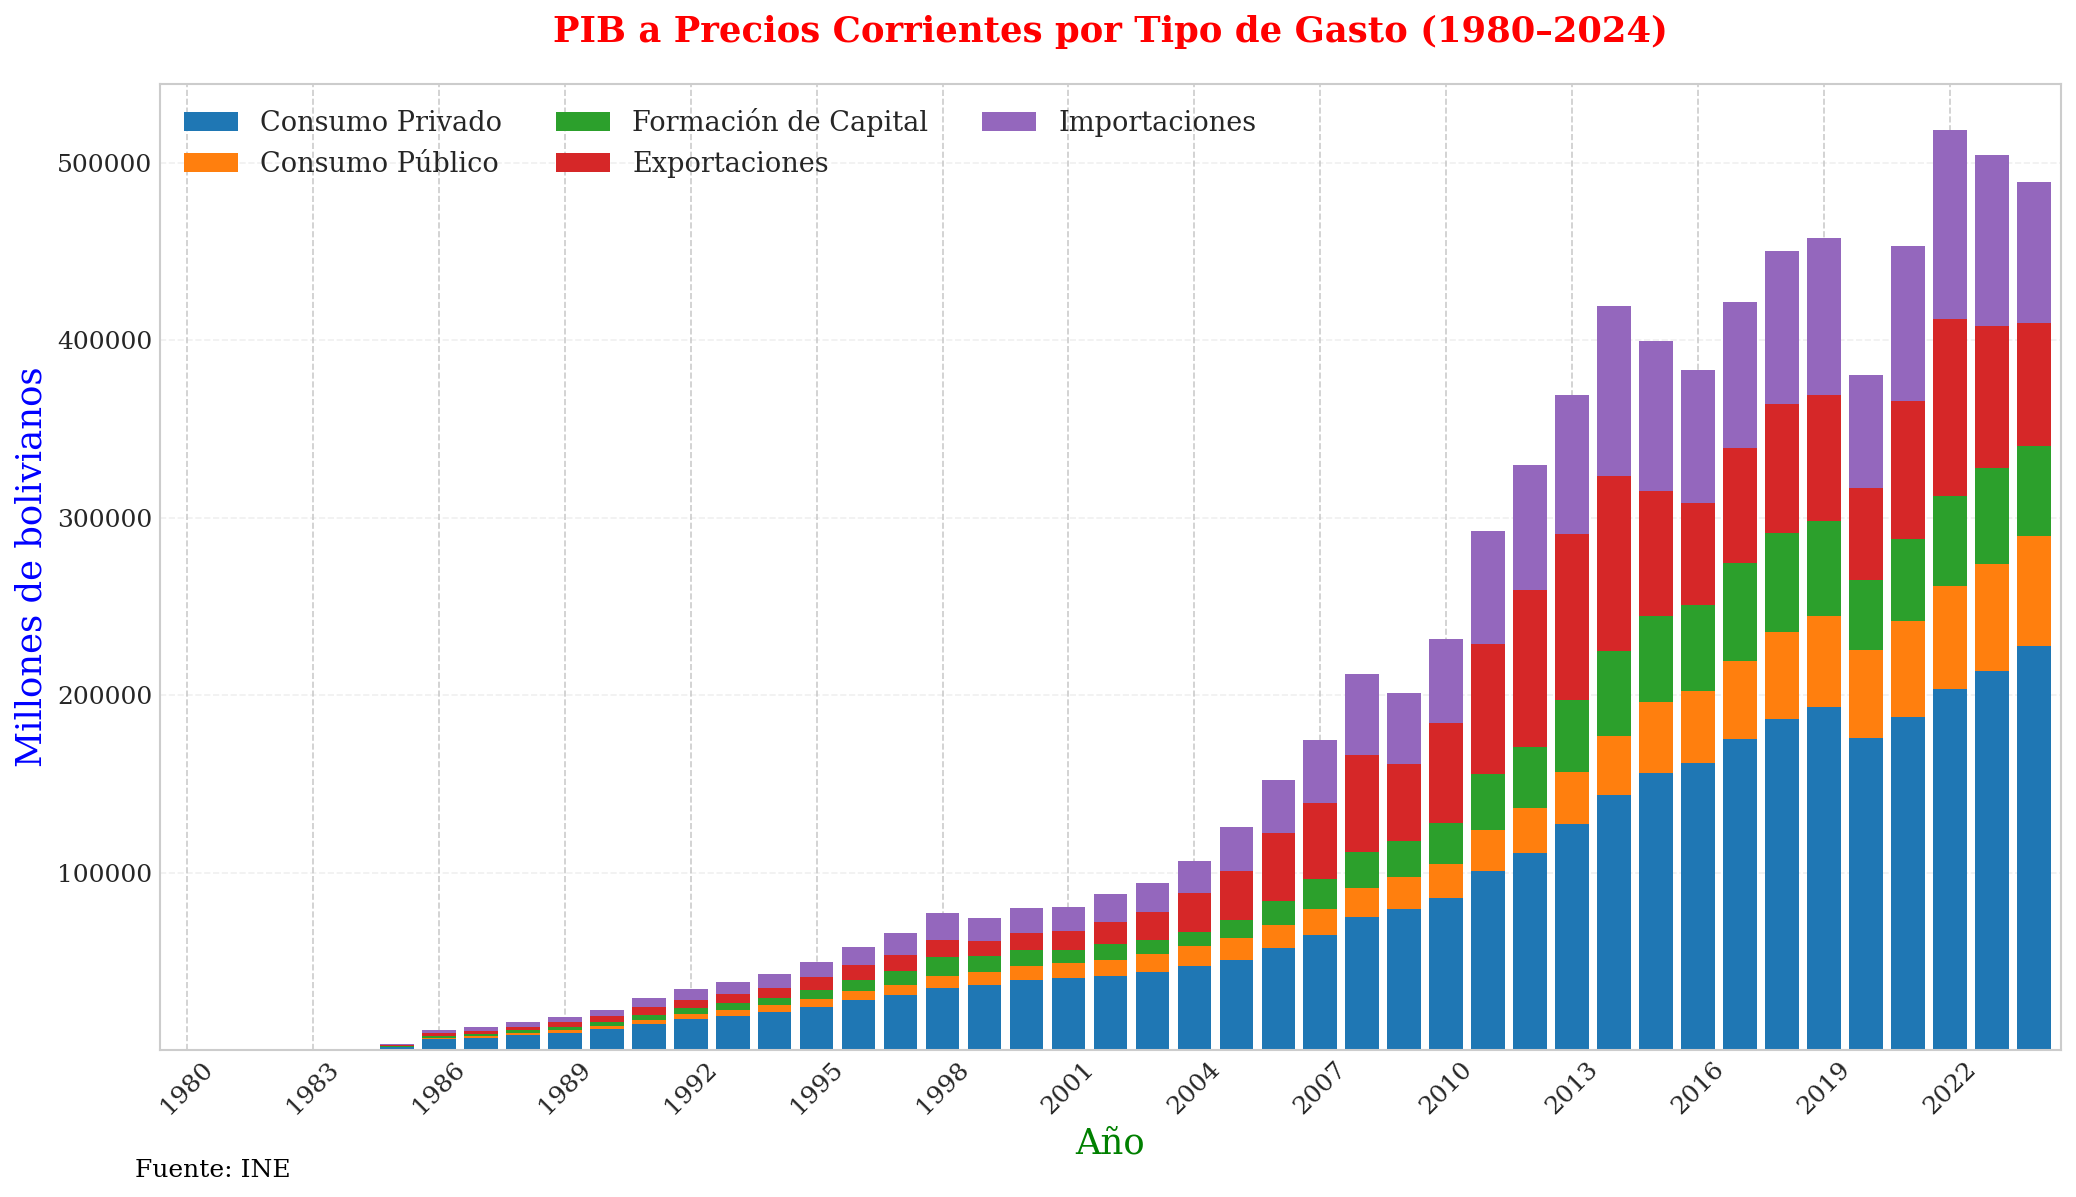

In [ ]:
# ───────────────────────────── IMPORTS ──────────────────────────────
import os
import sys
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

# IMPORTANTE: Importación correcta de las funciones auxiliares
from func_auxiliares.graficos_utils import (
    set_style,                          # Estilo corporativo
    init_base_plot,                     # Configuración base del gráfico
    add_hitos,                          # Líneas verticales de hitos
    add_cycle_means_multi,              # Medias por ciclo
    add_year_value_annotations,         # Anotaciones de valores por año
    add_period_growth_annotations_multi,# Tasas de crecimiento por período
    adjust_annot_years,                 # Ajustar años de anotación al DataFrame
    adjust_cycles,                      # Ajustar ciclos al DataFrame
    adjust_periods,                     # Ajustar períodos al DataFrame
)

from func_auxiliares.config import (
    DB_PATH,                            # Ruta a la base de datos
    CYCLES,                             # Diccionario de ciclos económicos
    annot_years,                        # Lista de años para anotaciones
    periodos_tasas,                     # Períodos para calcular tasas
    hitos_v,                            # Diccionario de hitos verticales
    ASSETS_DIR,
)

set_style()  # Aplica el estilo corporativo unificado
# ───────────────────────── 2. CARGA DE DATOS ────────────────────────
with sqlite3.connect(str(DB_PATH)) as conn:
    df = (
        pd.read_sql(
            "SELECT * FROM pib_nominal_gasto",
            conn,
            index_col="año"
        )
        .sort_index()
    )

# Convertir miles a millones para mejor legibilidad
valor_cols = ['gastos_consumo', 'consumo_privado', 'consumo_publico', 
              'formacion_capital', 'exportacion_bienes_servicios', 
              'importacion_bienes', 'pib_a_precios_corrientes']
df[valor_cols] = df[valor_cols] / 1000  # Miles a millones
df.head()
# ──────────────── 3. COMPONENTES Y PREPARACIÓN ──────────────────────
# Definir las series a graficar (tuplas de columna_df, etiqueta_display)
componentes = [
    ("consumo_privado", "Consumo Privado"),
    ("consumo_publico", "Consumo Público"),
    ("formacion_capital", "Formación de Capital"),
    ("exportacion_bienes_servicios", "Exportaciones"),
    ("importacion_bienes", "Importaciones"),
]

# Extraer solo los nombres de columnas
cols_componentes = [col for col, _ in componentes]

# Definir colores para cada serie
colors = {
    "consumo_privado": "#1f77b4",               # Azul
    "consumo_publico": "#ff7f0e",               # Naranja
    "formacion_capital": "#2ca02c",             # Verde
    "exportacion_bienes_servicios": "#d62728",  # Rojo
    "importacion_bienes": "#9467bd",            # Púrpura
}
# ────────────────────────── 6. GRÁFICO BASE (BARRAS APILADAS) ──────────────────────────
# Preparar DataFrame con columnas reordenadas y renombradas según componentes
cols, labels = zip(*componentes)
df_plot = df[list(cols)].copy()
df_plot.columns = labels

# Crear figura y ejes
fig, ax = plt.subplots(figsize=(14, 8))

# Graficar barras apiladas usando los colores corporativos definidos
colors_list = [colors[col] for col in cols]
df_plot.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors_list,
    width=0.8,
    edgecolor="none"
)

# Títulos y etiquetas (usando los mismos estilos corporativos)
ax.set_title(f"PIB a Precios Corrientes por Tipo de Gasto ({df.index.min()}–{df.index.max()})", 
             fontweight="bold", color="red", pad=20, fontsize=17)
ax.set_xlabel("Año", color="green", fontsize=17)
ax.set_ylabel("Millones de bolivianos", color="blue", fontsize=17)

# Configurar marcas en el eje X para mejorar legibilidad en barras
# (mostrando un salto para evitar que se superpongan)
num_years = len(df)
xtick_step = max(1, num_years // 15)
positions = range(num_years)
ax.set_xticks(positions[::xtick_step])
ax.set_xticklabels(df.index[::xtick_step], rotation=45)

# Leyenda corporativa
ax.legend(loc="upper left", ncol=3, fontsize=13)

# Grid sutil para el eje Y
ax.grid(True, axis="y", alpha=0.3, linestyle="--", zorder=0)
ax.set_axisbelow(True)

# Pie de fuente
fig.text(
    0.07, 0.005,
    "Fuente: Elaboracion propia en base a datos del INE",
    ha="left", va="bottom",
    fontsize=12, color="black",
    transform=fig.transFigure
)

plt.tight_layout()
plt.show()